In [65]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


1. Types of data & variables


In [66]:
# -----------------------------------------------------------
# 🔹 1A. NUMERICAL vs CATEGORICAL COLUMNS
# -----------------------------------------------------------

# .dtypes tells you each column's type: float/int = numerical, object/category = categorical
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)


total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [67]:
# -----------------------------------------------------------
# 🔹 1B. WHICH STATISTIC FITS WHICH TYPE
# -----------------------------------------------------------

# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [68]:
# 1. Numerical vs categorical columns
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


# 2. Mean of a numerical column (tip)
print("Mean of tip:", df['tip'].mean())


# 3. Value counts of a categorical column (sex)
print("Value counts of sex:")
print(df['sex'].value_counts())

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: []
Mean of tip: 2.99827868852459
Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


2. Measures of central tendency

In [69]:
# -----------------------------------------------------------
# 🔹 2A. MEAN, MEDIAN, MODE
# -----------------------------------------------------------

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


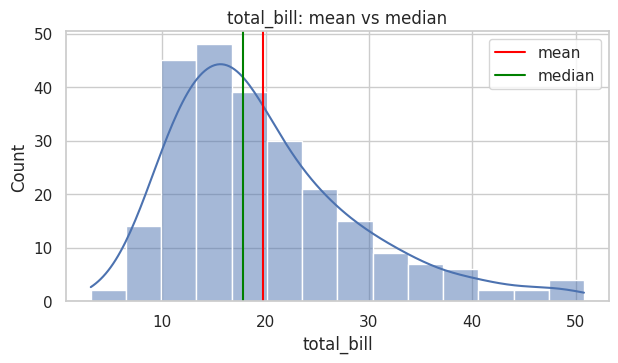

In [70]:
# -----------------------------------------------------------
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# -----------------------------------------------------------

# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

Mean: 2.99827868852459
Median: 2.9
Mode: [2.0]
Mean > Median: True
The tip distribution is right-skewed.


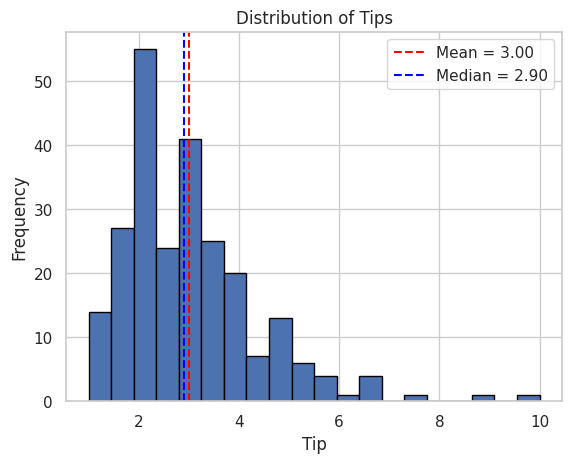

In [71]:
import matplotlib.pyplot as plt

tip = df['tip']

# 1. Mean, median, mode
mean_tip = tip.mean()
median_tip = tip.median()
mode_tip = tip.mode()

print("Mean:", mean_tip)
print("Median:", median_tip)
print("Mode:", mode_tip.tolist())


# 2. Is it right-skewed? Check whether mean > median
print("Mean > Median:", mean_tip > median_tip)

if mean_tip > median_tip:
    print("The tip distribution is right-skewed.")
else:
    print("The tip distribution is not right-skewed based on this check.")


# 3. Histogram with mean and median lines
plt.hist(tip, bins=20, edgecolor='black')

plt.axvline(mean_tip, color='red', linestyle='--',
            label=f'Mean = {mean_tip:.2f}')

plt.axvline(median_tip, color='blue', linestyle='--',
            label=f'Median = {median_tip:.2f}')

plt.xlabel('Tip')
plt.ylabel('Frequency')
plt.title('Distribution of Tips')
plt.legend()
plt.show()

3. Measures of spread (dispersion)

In [72]:
# -----------------------------------------------------------
# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION
# -----------------------------------------------------------

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)



Range : 47.74
Var   : 79.25
Std   : 8.9


In [73]:
# -----------------------------------------------------------
# 🔹 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
# -----------------------------------------------------------

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')


Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [74]:
tip = df['tip']

# 1. Range, variance, std
tip_range = tip.max() - tip.min()
tip_variance = tip.var()
tip_std = tip.std()

print("Range:", tip_range)
print("Variance:", tip_variance)
print("Standard deviation:", tip_std)


# 2. Q1, Q3, IQR
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


# 3. Most robust measure of spread
# IQR is the most robust because it is less affected by extreme
# values and outliers than the range, variance, and standard deviation.

Range: 9.0
Variance: 1.9144546380624725
Standard deviation: 1.3836381890011826
Q1: 2.0
Q3: 3.5625
IQR: 1.5625


4. Shape: five-number summary & box plot

In [75]:
# -----------------------------------------------------------
# 🔹 4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
# -----------------------------------------------------------

col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


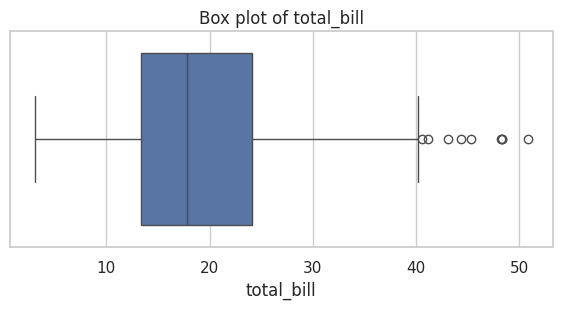

In [76]:
# -----------------------------------------------------------
# 🔹 4B. BOX PLOT (a picture of the five-number summary)
# -----------------------------------------------------------

# The box spans Q1..Q3 (the IQR), the line is the median,
# whiskers reach the rest, and dots beyond them are outliers.
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()


Five-number summary:
Min: 1.0
Q1 (25%): 2.0
Median (50%): 2.9
Q3 (75%): 3.5625
Max: 10.0
Skewness: 1.4654510370979401


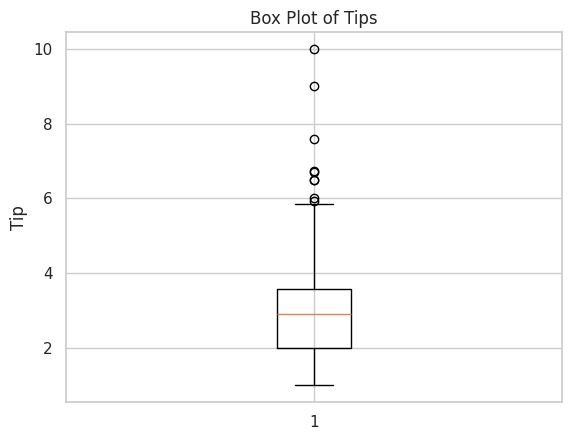

In [77]:
import matplotlib.pyplot as plt

tip = df['tip']

# 1. Five-number summary
five_number = tip.quantile([0, 0.25, 0.50, 0.75, 1.00])

print("Five-number summary:")
print("Min:", five_number.loc[0.00])
print("Q1 (25%):", five_number.loc[0.25])
print("Median (50%):", five_number.loc[0.50])
print("Q3 (75%):", five_number.loc[0.75])
print("Max:", five_number.loc[1.00])


# 2. Skewness (+ comment on the direction of the lean)
skewness = tip.skew()
print("Skewness:", skewness)

# Positive skewness means the distribution leans to the right.
# Negative skewness means the distribution leans to the left.
# Tip is typically right-skewed because skewness is positive.


# 3. Box plot of tip
plt.boxplot(tip)
plt.ylabel('Tip')
plt.title('Box Plot of Tips')
plt.show()

5. Correlation & summarizing a dataset

In [80]:
# -----------------------------------------------------------
# 🔹 5A. CORRELATION between numerical columns
# -----------------------------------------------------------

# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


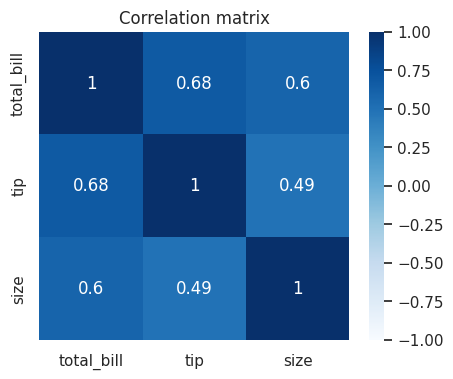

In [79]:
# -----------------------------------------------------------
# 🔹 5B. VISUALISE THE CORRELATION MATRIX
# -----------------------------------------------------------

plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()



In [78]:
# -----------------------------------------------------------
# 🔹 5C. ONE-SHOT SUMMARY with .describe()
# -----------------------------------------------------------

# describe() returns count, mean, std, min, quartiles and max for every numeric column
df.describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Correlation matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


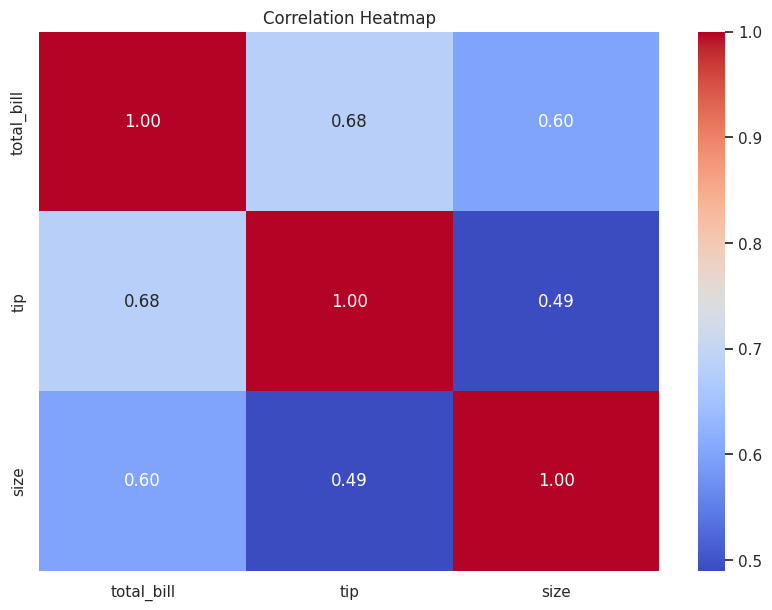

Dataset summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation matrix (rounded)
corr = df.corr(numeric_only=True).round(2)
print("Correlation matrix:")
print(corr)


# 2. Heatmap of the correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


# 3. df.describe()
print("Dataset summary:")
print(df.describe())


# Insight 1: The column with the largest standard deviation has the most spread.
# Insight 2: The pair with the largest absolute correlation is the most strongly correlated.
# Insight 3: If a column's mean is noticeably different from its median,
#            that column may be skewed.

# For the common Seaborn "tips" dataset:
# Insight 1: total_bill has the largest standard deviation among the main numeric columns.
# Insight 2: total_bill and tip have a strong positive correlation.
# Insight 3: tip is slightly right-skewed because its mean is greater than its median.